# Sistemas de Recomendación

**Objetivo:** construir un **sistema de recomendación** que, dado el perfil de una persona (edad, educación, ocupación, horas trabajadas, etc.), le sugiera qué trayectorias laborales o perfiles similares han logrado superar los $50K de ingresos anuales.

El proyecto:

1. Cargar el dataset
2. Limpiar y preprocesar los datos
3. Definir el problema de recomendación
4. Construir el sistema (filtrado basado en contenido)
5. Probar con usuarios simulados

## Imports

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# Similitud del coseno — el corazón del sistema de recomendación
from sklearn.metrics.pairwise import cosine_similarity

# EDA

## Paso 1 — Carga del conjunto de datos

* El data-set contiene información sobre ~32,000 personas adultas y la variable objetivo es si su ingreso anual supera los $50,000 o no.

In [2]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


> **Observaciones:** Parece que no existen nulos. Sin embargo en la representacion del data-frame vemos que hay valores en '?'.

In [4]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Paso 2 — Preprocesamiento de datos


- **Limpiar valores nulos o mal codificados** (p.ej. `?` en lugar de `NaN`)
- **Transformar variables categóricas** a números, porque los algoritmos solo entienden números
- **Normalizar variables numéricas** para que todas tengan la misma escala (de lo contrario, "edad" y "horas trabajadas" tendrían pesos diferentes solo por estar en escalas distintas)

### Limpieza de datos

* En este dataset, los valores faltantes están representados como '?', se reemplazan por NaN ya ue es un estándar de Python

In [5]:
df.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [6]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [7]:
# df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col) # limpieza de espacios en blanco inicio/fin es necesario? 

In [8]:
filas_antes = len(df)
df.dropna(inplace=True)
filas_despues = len(df)

print(f'Filas antes: {filas_antes}')
print(f'Filas después: {filas_despues}')
print(f'Filas eliminadas: {filas_antes - filas_despues} ({(filas_antes - filas_despues)/filas_antes*100:.1f}%)')

Filas antes: 32561
Filas después: 30162
Filas eliminadas: 2399 (7.4%)


> **Observaciones y conclusiones:**  
> Eliminamos filas con valores nulos, representan aproximadamente 7% del dataset, podemos eliminarlos sin perder mucha información.

**Distribución de 'income' con datos normalizados:** 

In [9]:
print(df['income'].value_counts())
print()
print(df['income'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

income
<=50K    22654
>50K      7508
Name: count, dtype: int64

income
<=50K    75.1%
>50K     24.9%
Name: proportion, dtype: str


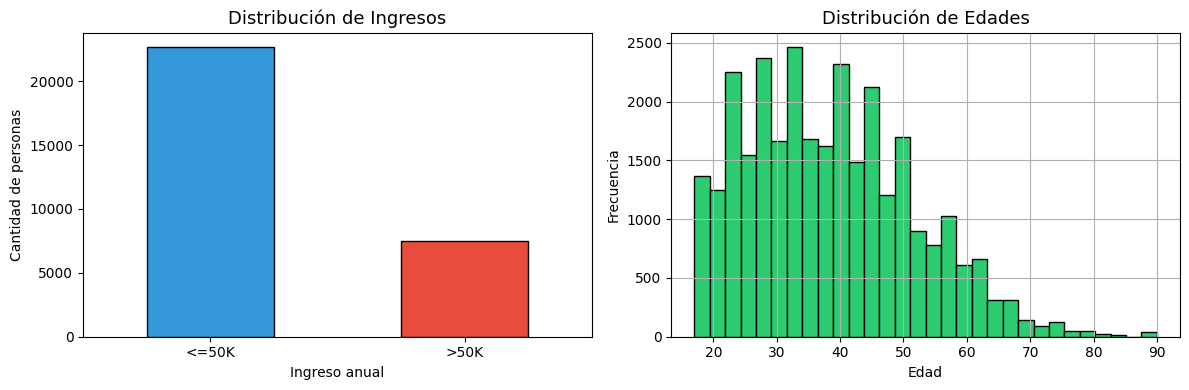

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución por ingresos
df['income'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribución de Ingresos', fontsize=13)
axes[0].set_xlabel('Ingreso anual')
axes[0].set_ylabel('Cantidad de personas')
axes[0].tick_params(axis='x', rotation=0)

# Distribución por edad
df['age'].hist(bins=30, ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Distribución de Edades', fontsize=13)
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Selección de columnas relevantes para el análisis

* Se usarán las columnas que mejor describen el **perfil laboral y educativo** de una persona:

In [11]:
columnas_perfil = [
    'age',            # Edad (numérica)
    'education',      # Nivel educativo (categórica)
    'education.num',  # Años de educación (numérica) — versión numérica de 'education'
    'occupation',     # Ocupación (categórica)
    'hours.per.week', # Horas trabajadas por semana (numérica)
    'sex',            # Sexo (categórica)
    'marital.status', # Estado civil (categórica)
    'income'          # Variable objetivo — lo que queremos predecir/recomendar
]

# Creamos una copia limpia con solo esas columnas
df_perfil = df[columnas_perfil].copy()

print(f'Dimensiones del dataset de perfil: {df_perfil.shape}')
df_perfil.head()

Dimensiones del dataset de perfil: (30162, 8)


,age,education,education.num,occupation,hours.per.week,sex,marital.status,income
1,82,HS-grad,9,Exec-managerial,18,Female,Widowed,<=50K
3,54,7th-8th,4,Machine-op-inspct,40,Female,Divorced,<=50K
4,41,Some-college,10,Prof-specialty,40,Female,Separated,<=50K
5,34,HS-grad,9,Other-service,45,Female,Divorced,<=50K
6,38,10th,6,Adm-clerical,40,Male,Separated,<=50K


### Codificación de variables categóricas

**¿Por qué necesitamos esto?**
Los algoritmos de similitud trabajan con vectores numéricos. "Occupation = Tech-support" no le dice nada a una computadora hasta que lo convertimos en un número.

Usaremos **LabelEncoder**, que asigna un número entero a cada categoría.

In [12]:
cols_categoricas = df_perfil.select_dtypes(include='object').columns.tolist()
df_features = df_perfil.drop(columns=['income']).copy()
y_income = df_perfil['income'].copy()

/tmp/ipykernel_941/1354241866.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_perfil.select_dtypes(include='object').columns.tolist()


In [13]:
le = LabelEncoder()
cols_cat_features = df_features.select_dtypes(include='object').columns.tolist()

/tmp/ipykernel_941/3464248150.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat_features = df_features.select_dtypes(include='object').columns.tolist()


In [14]:
for col in cols_cat_features:
    df_features[col] = le.fit_transform(df_features[col])
    print(f'{col} codificada')

df_features.head()

education codificada
occupation codificada
sex codificada
marital.status codificada


,age,education,education.num,occupation,hours.per.week,sex,marital.status
1,82,11,9,3,18,0,6
3,54,5,4,6,40,0,0
4,41,15,10,9,40,0,5
5,34,11,9,7,45,0,0
6,38,0,6,0,40,1,5


### Normalización de variables numéricas

**¿Por qué normalizar?**
Si `age` va de 17 a 90 y `hours.per.week` va de 1 a 99, la distancia entre vectores estará dominada por `age` simplemente porque tiene valores más grandes. Normalizamos todo al rango [0, 1] para que todas las variables tengan el mismo peso.

Usamos **MinMaxScaler**:

In [15]:
scaler = MinMaxScaler()
X_normalizado = scaler.fit_transform(df_features)

# Convertimos de vuelta a DataFrame para mantener los nombres de columnas
df_normalizado = pd.DataFrame(X_normalizado, columns=df_features.columns)

print('Rango de valores después de normalizar:')
print(df_normalizado.describe().loc[['min', 'max']])

Rango de valores después de normalizar:
     age  education  education.num  occupation  hours.per.week  sex  \
min  0.0        0.0            0.0         0.0             0.0  0.0   
max  1.0        1.0            1.0         1.0             1.0  1.0   

     marital.status  
min             0.0  
max             1.0  


## Paso 3 — Definir el problema de recomendación

**¿Qué queremos recomendar?**

* Trayectorias laborales: combinaciones de (educación + ocupación + horas de trabajo) que están asociadas con ingresos mayores a $50K.

**¿Quién es el "usuario"?** 
* Una persona con un perfil dado: tiene cierta edad, nivel educativo, estado civil y ocupación actual. El sistema le dirá qué perfiles similares lograron ingresos altos.

**¿Qué variables definen el perfil?**
- `age` — la edad importa en la trayectoria laboral
- `education.num` — años de educación formal
- `occupation` — qué tipo de trabajo tiene
- `hours.per.week` — dedicación laboral
- `sex` — variable sociodemográfica
- `marital.status` — afecta el contexto económico

**Filtrado Basado en Contenido:** 

* Representamos a cada persona como un vector de características. Para recomendar, calculamos la similitud del coseno entre el perfil nuevo y todos los perfiles que ganan >$50K. Los más similares son las mejores recomendaciones.

### Separamos el dataset en dos grupos:

In [16]:

mask_alto_ingreso = (y_income == '>50K').values
mask_bajo_ingreso = (y_income == '<=50K').values

df_alto_ingreso = df_normalizado[mask_alto_ingreso].reset_index(drop=True)
df_original_alto = df_perfil[mask_alto_ingreso].reset_index(drop=True)  # sin normalizar, para mostrar

print(f'Perfiles con ingreso >50K:  {df_alto_ingreso.shape[0]:,}')
print(f'Perfiles con ingreso <=50K: {df_normalizado[mask_bajo_ingreso].shape[0]:,}')
print()
df_original_alto.head()

Perfiles con ingreso >50K:  7,508
Perfiles con ingreso <=50K: 22,654



,age,education,education.num,occupation,hours.per.week,sex,marital.status,income
0,74,Doctorate,16,Prof-specialty,20,Female,Never-married,>50K
1,45,Doctorate,16,Prof-specialty,35,Female,Divorced,>50K
2,38,Prof-school,15,Prof-specialty,45,Male,Never-married,>50K
3,52,Bachelors,13,Other-service,20,Female,Widowed,>50K
4,32,Masters,14,Exec-managerial,55,Male,Separated,>50K


## Paso 4 — Construir el sistema de recomendación

### Teoría: Similitud del Coseno



La similitud del coseno mide qué tan parecidos son dos vectores basándose en el **ángulo** entre ellos (no su magnitud):

$$\text{similitud}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

- Resultado = 1 → los vectores son idénticos (apuntan en la misma dirección)
- Resultado = 0 → los vectores son perpendiculares (nada en común)

En nuestro caso: **A** = perfil del usuario nuevo, **B** = perfil de alguien que gana >50K.
Buscamos los perfiles **B** con similitud más alta.



### La función de recomendación

Dado el perfil de un usuario (sin normalizar), encuentra los N perfiles más similares que ganan >50K y los devuelve como recomendaciones.
    
Parámetros:
  
1. perfil_usuario : dict
* Diccionario con las características del usuario.
* Claves: age, education, education.num, occupation, hours.per.week, sex, marital.status
    
2. n_recomendaciones : int
* Número de perfiles similares a retornar (por defecto 5)
    
Retorna: DataFrame con los perfiles más similares y su puntuación de similitud


In [18]:
def recomendar_trayectorias(perfil_usuario, n_recomendaciones=5):
        
    # --- Paso 1: Convertir el perfil del usuario a DataFrame ---
    usuario_df = pd.DataFrame([perfil_usuario])
    
    # --- Paso 2: Codificar las variables categóricas ---
    # Para codificar al usuario, necesitamos los mismos encoders que usamos con el dataset
    # Usamos el dataset original para 'mapear' los valores a números
    usuario_encoded = usuario_df.copy()
    
    for col in cols_cat_features:
        if col in usuario_encoded.columns:
            # Mapeamos usando el mismo LabelEncoder entrenado con df_features
            # Para simplicidad, usamos el mapeo del dataset directamente
            le_temp = LabelEncoder()
            le_temp.fit(df_features_original[col])  # fit con el dataset completo
            usuario_encoded[col] = le_temp.transform(usuario_encoded[col])
    
    # --- Paso 3: Normalizar con el mismo scaler del dataset ---
    usuario_normalizado = scaler.transform(usuario_encoded[df_features.columns])
    
    # --- Paso 4: Calcular similitud del coseno ---
    # Comparamos el vector del usuario con todos los perfiles de >50K
    similitudes = cosine_similarity(usuario_normalizado, df_alto_ingreso.values)
    # similitudes es una matriz 1 × N, tomamos la primera fila
    similitudes = similitudes[0]
    
    # --- Paso 5: Ordenar de mayor a menor similitud ---
    indices_top = np.argsort(similitudes)[::-1][:n_recomendaciones]
    
    # --- Paso 6: Armar el resultado ---
    resultado = df_original_alto.iloc[indices_top].copy()
    resultado['similitud'] = similitudes[indices_top].round(4)
    resultado = resultado.drop(columns=['income'])  # la quitamos, sabemos que es >50K
    resultado.insert(0, 'similitud', resultado.pop('similitud'))
    
    return resultado.reset_index(drop=True)


# Guardamos el df_features antes de codificar (necesario en la función)
df_features_original = df_perfil.drop(columns=['income']).copy()

## Paso 5 — Pruebas con usuarios simulados

### Usuario 1: Persona joven con educación media y trabajo part-time

**Joven con secundario completo, trabaja pocas horas**


In [20]:
usuario_1 = {
    'age': 25,
    'education': 'HS-grad',       # Graduado de secundaria
    'education.num': 9,
    'occupation': 'Adm-clerical', # Trabajo administrativo
    'hours.per.week': 25,
    'sex': 'Male',
    'marital.status': 'Never-married'
}

print('Perfil del Usuario 1:')
for k, v in usuario_1.items():
    print(f'   {k}: {v}')
print()

recomendaciones_1 = recomendar_trayectorias(usuario_1, n_recomendaciones=5)
print('Trayectorias recomendadas (perfiles similares con ingresos >$50K):')
recomendaciones_1

Perfil del Usuario 1:
   age: 25
   education: HS-grad
   education.num: 9
   occupation: Adm-clerical
   hours.per.week: 25
   sex: Male
   marital.status: Never-married

Trayectorias recomendadas (perfiles similares con ingresos >$50K):


,similitud,age,education,education.num,occupation,hours.per.week,sex,marital.status
0,0.9917,35,HS-grad,9,Adm-clerical,40,Male,Never-married
1,0.9898,34,HS-grad,9,Adm-clerical,40,Male,Separated
2,0.9893,31,HS-grad,9,Craft-repair,40,Male,Never-married
3,0.9883,33,HS-grad,9,Craft-repair,40,Male,Never-married
4,0.9870,24,Assoc-voc,11,Adm-clerical,30,Male,Never-married


=== ANÁLISIS: ¿Qué ocupaciones caracterizan los perfiles recomendados? ===


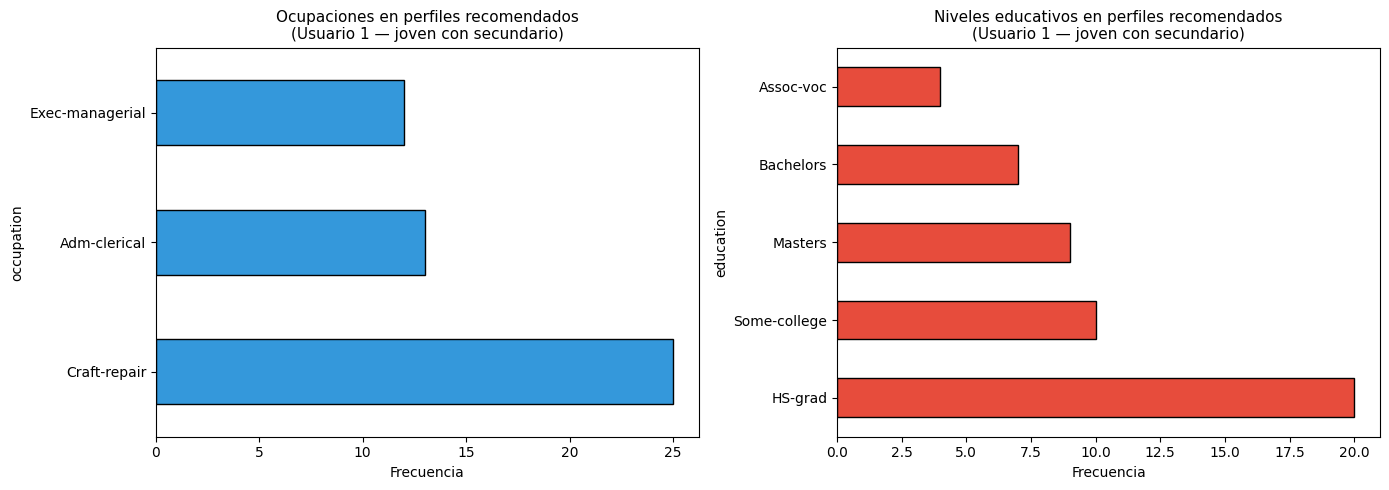

In [21]:
# Visualizamos qué ocupaciones aparecen más en las recomendaciones del usuario 1
print('=== ANÁLISIS: ¿Qué ocupaciones caracterizan los perfiles recomendados? ===')

# Tomamos más recomendaciones para el análisis
top_20 = recomendar_trayectorias(usuario_1, n_recomendaciones=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ocupaciones más frecuentes
top_20['occupation'].value_counts().head(8).plot(
    kind='barh', ax=axes[0], color='#3498db', edgecolor='black'
)
axes[0].set_title('Ocupaciones en perfiles recomendados\n(Usuario 1 — joven con secundario)', fontsize=11)
axes[0].set_xlabel('Frecuencia')

# Nivel educativo
top_20['education'].value_counts().head(8).plot(
    kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black'
)
axes[1].set_title('Niveles educativos en perfiles recomendados\n(Usuario 1 — joven con secundario)', fontsize=11)
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

###  Usuario 2: Mujer de mediana edad con carrera universitaria

**Mujer con título universitario, casada, trabajadora de tiempo completo**

In [22]:
usuario_2 = {
    'age': 38,
    'education': 'Bachelors',         # Licenciatura universitaria
    'education.num': 13,
    'occupation': 'Prof-specialty',   # Trabajo profesional/especializado
    'hours.per.week': 40,
    'sex': 'Female',
    'marital.status': 'Married-civ-spouse'
}

print('Perfil del Usuario 2:')
for k, v in usuario_2.items():
    print(f'   {k}: {v}')
print()

recomendaciones_2 = recomendar_trayectorias(usuario_2, n_recomendaciones=5)
print('Trayectorias recomendadas (perfiles similares con ingresos >$50K):')
recomendaciones_2

Perfil del Usuario 2:
   age: 38
   education: Bachelors
   education.num: 13
   occupation: Prof-specialty
   hours.per.week: 40
   sex: Female
   marital.status: Married-civ-spouse

Trayectorias recomendadas (perfiles similares con ingresos >$50K):


,similitud,age,education,education.num,occupation,hours.per.week,sex,marital.status
0,1.0,38,Bachelors,13,Prof-specialty,40,Female,Married-civ-spouse
1,1.0,38,Bachelors,13,Prof-specialty,40,Female,Married-civ-spouse
2,1.0,38,Bachelors,13,Prof-specialty,40,Female,Married-civ-spouse
3,1.0,38,Bachelors,13,Prof-specialty,40,Female,Married-civ-spouse
4,1.0,38,Bachelors,13,Prof-specialty,40,Female,Married-civ-spouse


### Usuario 3: Persona mayor sin estudios universitarios, trabajo manual

**Persona mayor, sin título universitario, trabajo manual**

In [23]:
usuario_3 = {
    'age': 52,
    'education': 'Some-college',      # Algo de universidad pero sin título
    'education.num': 10,
    'occupation': 'Craft-repair',     # Trabajo de mantenimiento/artesanía
    'hours.per.week': 50,             # Trabaja muchas horas
    'sex': 'Male',
    'marital.status': 'Married-civ-spouse'
}

print('👨 Perfil del Usuario 3:')
for k, v in usuario_3.items():
    print(f'   {k}: {v}')
print()

recomendaciones_3 = recomendar_trayectorias(usuario_3, n_recomendaciones=5)
print('💡 Trayectorias recomendadas (perfiles similares con ingresos >$50K):')
recomendaciones_3

👨 Perfil del Usuario 3:
   age: 52
   education: Some-college
   education.num: 10
   occupation: Craft-repair
   hours.per.week: 50
   sex: Male
   marital.status: Married-civ-spouse

💡 Trayectorias recomendadas (perfiles similares con ingresos >$50K):


,similitud,age,education,education.num,occupation,hours.per.week,sex,marital.status
0,0.9999,51,Some-college,10,Craft-repair,48,Male,Married-civ-spouse
1,0.9998,50,Some-college,10,Craft-repair,48,Male,Married-civ-spouse
2,0.9997,49,Some-college,10,Craft-repair,50,Male,Married-civ-spouse
3,0.9996,52,Some-college,10,Craft-repair,45,Male,Married-civ-spouse
4,0.9995,56,Some-college,10,Craft-repair,50,Male,Married-civ-spouse


### Comparación entre los tres usuarios

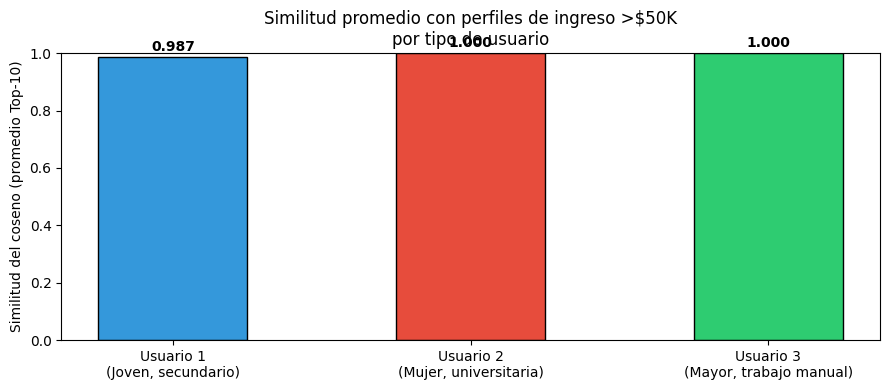


💡 Interpretación:
  - Una similitud más alta significa que hay más perfiles parecidos al usuario con ingresos altos
  - Una similitud más baja indica que el usuario está más lejos de los perfiles de alto ingreso


In [24]:
# Comparamos las similitudes promedio de cada usuario con sus recomendaciones
top_u1 = recomendar_trayectorias(usuario_1, n_recomendaciones=10)
top_u2 = recomendar_trayectorias(usuario_2, n_recomendaciones=10)
top_u3 = recomendar_trayectorias(usuario_3, n_recomendaciones=10)

fig, ax = plt.subplots(figsize=(9, 4))

usuarios = ['Usuario 1\n(Joven, secundario)', 'Usuario 2\n(Mujer, universitaria)', 'Usuario 3\n(Mayor, trabajo manual)']
similitudes_promedio = [
    top_u1['similitud'].mean(),
    top_u2['similitud'].mean(),
    top_u3['similitud'].mean()
]

bars = ax.bar(usuarios, similitudes_promedio, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
ax.set_title('Similitud promedio con perfiles de ingreso >$50K\npor tipo de usuario', fontsize=12)
ax.set_ylabel('Similitud del coseno (promedio Top-10)')
ax.set_ylim(0, 1)

# Añadir etiquetas encima de las barras
for bar, val in zip(bars, similitudes_promedio):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print()
print('💡 Interpretación:')
print('  - Una similitud más alta significa que hay más perfiles parecidos al usuario con ingresos altos')
print('  - Una similitud más baja indica que el usuario está más lejos de los perfiles de alto ingreso')

## Análisis de qué caracteriza a los perfiles de alto ingreso

**¿Qué ocupaciones están más asociadas con ingresos >50K?**

=== TOP OCUPACIONES CON MAYOR TASA DE INGRESO >$50K ===


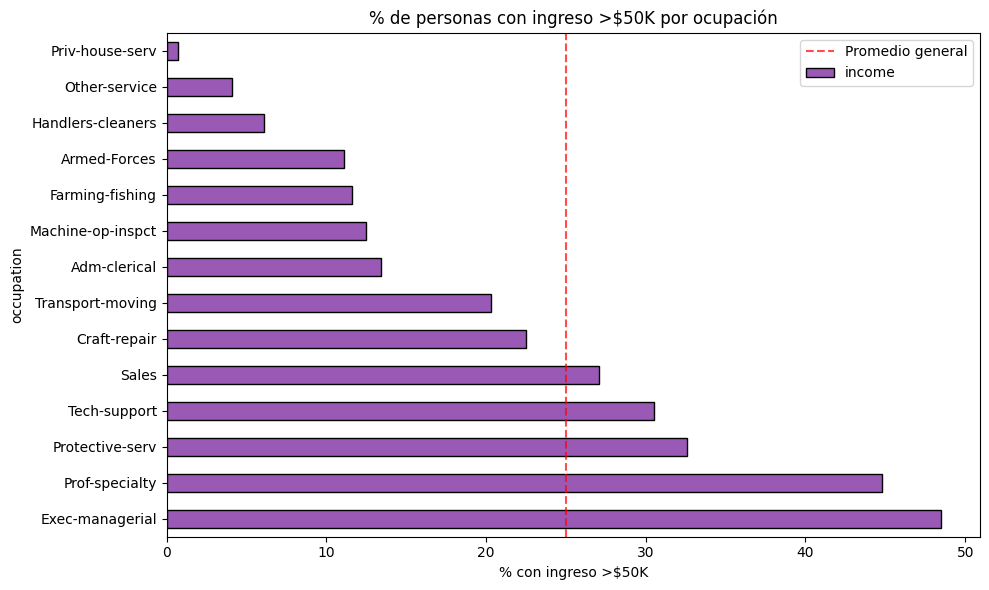

In [25]:

print('=== TOP OCUPACIONES CON MAYOR TASA DE INGRESO >$50K ===')

tasa_por_ocupacion = (
    df_perfil.groupby('occupation')['income']
    .apply(lambda x: (x == '>50K').mean() * 100)
    .sort_values(ascending=False)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 6))
tasa_por_ocupacion.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('% de personas con ingreso >$50K por ocupación', fontsize=12)
ax.set_xlabel('% con ingreso >$50K')
ax.axvline(x=25, color='red', linestyle='--', alpha=0.7, label='Promedio general')
ax.legend()
plt.tight_layout()
plt.show()

**¿Qué nivel educativo está más asociado con ingresos altos?**

=== NIVEL EDUCATIVO VS INGRESO ===


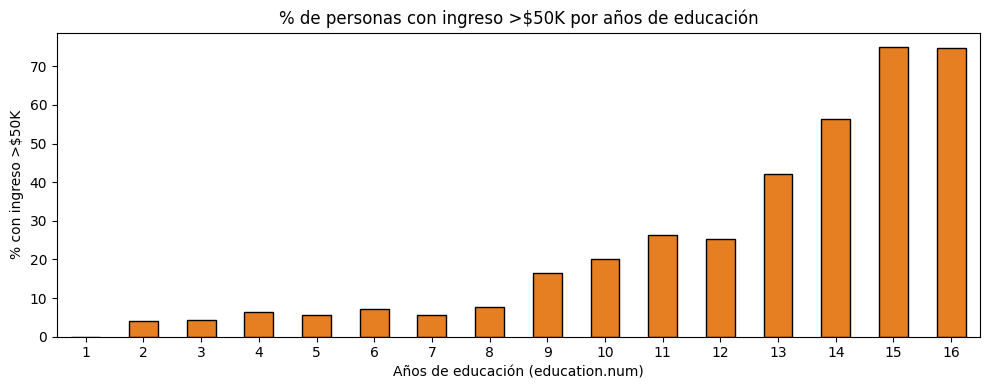


💡 Observación: La probabilidad de tener un ingreso >$50K aumenta claramente con los años de educación.
   A partir de 13 años de educación (nivel universitario), la tasa supera el 40%.


In [ ]:
print('=== NIVEL EDUCATIVO VS INGRESO ===')

tasa_por_educacion = (
    df_perfil.groupby('education.num')['income']
    .apply(lambda x: (x == '>50K').mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 4))
tasa_por_educacion.plot(kind='bar', ax=ax, color='#e67e22', edgecolor='black')
ax.set_title('% de personas con ingreso >$50K por años de educación', fontsize=12)
ax.set_xlabel('Años de educación (education.num)')
ax.set_ylabel('% con ingreso >$50K')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('\nObservación: La probabilidad de tener un ingreso >$50K aumenta claramente con los años de educación.')
print('   A partir de 13 años de educación (nivel universitario), la tasa supera el 40%.')

## Conclusiones

### ¿Qué construimos?


Un **sistema de recomendación basado en contenido** que:
1. Representa a cada persona como un **vector numérico** de características laborales y educativas
2. Calcula la **similitud del coseno** entre un perfil nuevo y todos los perfiles que ganan >$50K
3. Devuelve los perfiles más similares como **trayectorias recomendadas**



### Observaciones clave:


- Las ocupaciones **Exec-managerial** y **Prof-specialty** tienen las mayores tasas de ingreso >$50K
- La educación universitaria (13+ años) está fuertemente correlacionada con ingresos altos
- El sistema es más útil como **orientación vocacional** que como predictor exacto



### Limitaciones del enfoque:


- **Sesgo histórico**: El dataset fue recopilado en los años 90, los patrones pueden haber cambiado
- **Sobre-especialización**: El sistema solo recomienda perfiles muy similares al usuario
- **Codificación simple**: LabelEncoder no captura la "distancia" real entre categorías



### ¿Cómo mejoraría el sistema?


- Usar **One-Hot Encoding** en lugar de LabelEncoder para variables nominales
- Implementar **filtrado colaborativo** para descubrir trayectorias inesperadas
- Añadir un componente híbrido que combine similitud de contenido con patrones grupales